# Tabular data and `pandas`

## Introduction

So far this week, we have seen how we can begin to begin to more efficiently large numerical data, and also visualise the outputs. However, this hasn't exactly been convenient - we need to keep track of all our different variables and ensure they remain the same format and length for easy plotting.

There is a solution to this: a package called `pandas`. The [official documentation states that](https://pandas.pydata.org/) "_`pandas` aims to be the fundamental high-level building block for doing practical, real world data analysis in Python_". In short, you can think of this as an analogous tool to Microsoft Excel: it allows us to keep all our data togther in a _tabular_ format (i.e. spreadsheets), allowing us to add new data as rows and columns manipulate, clean, analyse, and explore the data. It is particularly strong at dealing with time-series data, which is useful for a wide range of spatio-temporal analysis.

We usually import `pandas` under the name `pd`:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## The Pandas `DataFrame`

The base unit of pandas is ` DataFrame`, a 2-D, columnar structure that will be familiar to anyone who has worked with spreadsheets before.

```{figure} ../../img/pandas_dataframe.svg
:alt: pandas dataframe anatomy
:class: bh-primary
:width: 450px
:align: center
Anatomy of a pandas dataframe (Credit: [Project Pythia](https://foundations.projectpythia.org/build/0d827165ba9c730294f2e615e0d2bf86.svg))
```

### `Series`

A single column of a pandas `DataFrame` is referred to as `Series`. This is one-dimensional array holding data of any type. In practice, you won't have to think about `Series` too much - pandas will happily accept a wide variety of 1-D data (`list`, `tuple`, `np.array`, etc.) and turn it into a `Series` behind-the-scenes.

All pandas object have an `index` that allows individual rows to be tied together. By default, this starts from `0` (matching our previous knowledge about indexing) -- but it could just as easily be another data range - e.g. dates or times.

In [2]:
array = np.array([10, 20, 30, 40, 50])
series = pd.Series(array)

# Note the index of the series is automatically generated as 0, 1, 2, 3, 4. 
# The dtype of the series is inferred from the data in the array, which is int64 in this case.

print(series)

0    10
1    20
2    30
3    40
4    50
dtype: int64


In [3]:
index = ['a', 'b', 'c', 'd', 'e']
series_with_index = pd.Series(array, index=index)

print(series_with_index)

a    10
b    20
c    30
d    40
e    50
dtype: int64


With an index, you can now access individual items using their index label. To access via their traditional position-based index number (`0`, `1`, `-1` etc.), you have to use the specific command `.iloc[n]`, where `n` is a integer for position.

In [4]:
print("Accessing value at index 'c':", series_with_index['c'])  # Accessing the value associated with index 'c'

print("Accessing values at indices 'a' and 'e':\n", series_with_index[['a', 'e']])  # Accessing values associated with indices 'a' and 'e'

print("Accessing values at position 0:", series_with_index.iloc[0])  # This will return a boolean series indicating which values are greater than 25

Accessing value at index 'c': 30
Accessing values at indices 'a' and 'e':
 a    10
e    50
dtype: int64
Accessing values at position 0: 10


### `DataFrames`

We can string together series of 1-D datasets into a single `DataFrame`. You can think of this as just being a particularly fancy `dict`: in fact, the easiest way to construct a `DataFrame` from scratch is to feed the `pd.DataFrame` funcion a dictionary! Each key-value pair represents a column in the DataFrame. The keys become the column names, and the values (which are 1-D lists) become the data for those columns.

In [5]:
data = {
    "names": ["Alice", "Bob", "Charlie", "David", "Eva"],
    "ages": [25, 30, 35, 40, 45],
    "cities": ["New York", "London", "Tokyo", "Paris", "Berlin"],
    "commute_times": [30, 45, 20, 25, 35],
    "commute_modes": ["Car", "Bus", "Train", "Bicycle", "Walking"],
}

# traditionally, a DataFrame variable is referred to as df, but you can name it anything you like 
df = pd.DataFrame(data)

# Note we haven't specified an index, so pandas will automatically generate one for us (0, 1, 2, 3, 4).
df

,names,ages,cities,commute_times,commute_modes
0,Alice,25,New York,30,Car
1,Bob,30,London,45,Bus
2,Charlie,35,Tokyo,20,Train
3,David,40,Paris,25,Bicycle
4,Eva,45,Berlin,35,Walking


Now we can extract individual rows or columns

In [6]:
df.iloc[2]  # returns the row at position 2 (the third row, since indexing starts at 0)

names            Charlie
ages                  35
cities             Tokyo
commute_times         20
commute_modes      Train
Name: 2, dtype: object

In [7]:
df['cities']  # returns the 'cities' column as a Series

0    New York
1      London
2       Tokyo
3       Paris
4      Berlin
Name: cities, dtype: object

## Importing Data

Now (finally, after nearly two weeks!) we have the tools in place to begin to explore some real data. 

Pandas has the functions to read a wide variety of default tabular data, such as comma-seperated variable (`.csv`) files using `pd.read_csv`, or even Excel spreadsheets (`.xlsx`) using (`pd.read_excel`). It is recommended that, for most programming purposes that aren't using very large (e.g. hundreds of megabytes) worth of data, you try and work using CSV files: these are simple, plain-text files that store data efficiently and in a human-readable manner.

We'll begin with something iconic: the [monthly record of atmospheric carbon dioxide variabtions at Mauna Loa Observatory, Hawaii](https://gml.noaa.gov/ccgg/trends/data.html). You can download the class copy of this dataset [by clicking this link](https://raw.githubusercontent.com/trchudley/geospatial-scientific-computing/main/week/02/co2_mm_mlo.csv) (this may begin the download automatically, or you may have to manually 'save' the page. Be sure to save it under the file name `co2_mm_mlo.csv` for the below to work). 

Download the file to the same directory as the Juptyer Notebook you are using. Try and open it if you like: you will see the meaning of the term 'comma-seperated',  as the data is stored in plaintext rows with columns seperated by commas.

We can read the data using `pd.read_csv()`, with the main argument being the filepath of our desired dataset. If the data is in the same directory as our Jupyter Notebook or Python file, we can just use the file name:

In [8]:
co2_df = pd.read_csv('co2_mm_mlo.csv')

co2_df

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
0,1958,3,1958.2027,315.71,314.44,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.69,-1,-9.99,-0.99
3,1958,6,1958.4548,317.27,315.15,-1,-9.99,-0.99
4,1958,7,1958.5370,315.87,315.20,-1,-9.99,-0.99
...,...,...,...,...,...,...,...,...
817,2026,4,2026.2917,431.12,428.61,23,1.16,0.46
818,2026,5,2026.3750,432.34,429.06,19,0.64,0.28
819,2026,6,2026.4583,431.43,428.99,19,0.27,0.12
820,2026,7,2026.5417,429.13,428.78,21,0.61,0.26


Notes on column meanings:
 - `year`: The year of the measurement.
 - `month`: The month of the measurement.
 - `decimal_date`: The decimal representation of the date (e.g., 2020.5 for mid-2020).
 - `average`: The average CO2 concentration for that month (in parts per million).
 - `deasonalized`: The CO2 concentration after removing seasonal variations.
 - `ndays`: The number of days in the month for which measurements were taken. -1 indicates that the number of days is not available.
 - `sdev`: The standard deviation of the CO2 measurements for that month. -9.99 indicates that the standard deviation is not available.
 - `unc`: The uncertainty associated with the CO2 measurements for that month. -0.99 indicates that the uncertainty is not available.

### Cleaning data: null values

Great, we have some data! But you can see that there might be some work to do on it before we begin exploring the data.

The first is that the 'null' or 'nodata' values are expressed as negative numbers in different columns. This will mess with our attempts to perform statistical analysis (e.g. getting running averages), as `pandas` doesn't "know" like we do that these data should be ignored.

Here, we can do this with the  `.replace()` function: this replaces all instances of the first argument with the second. We will use the `np.nan` value to fill in the empty columns: `NaN` stands for "Not A Number", and is recognised across a wide range of scientic Python packages.

In [9]:
# replace values of -1 in `ndays` with NaN
co2_df['ndays'] = co2_df['ndays'].replace(-1, np.nan)

# replace values of -99.99 in column 'sdev' with NaN
co2_df['sdev'] = co2_df['sdev'].replace(-9.99, np.nan)

# replace values of -0.99 in column 'unc' with NaN
co2_df['unc'] = co2_df['unc'].replace(-0.99, np.nan)

co2_df


,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
0,1958,3,1958.2027,315.71,314.44,NaN,NaN,NaN
1,1958,4,1958.2877,317.45,315.16,NaN,NaN,NaN
2,1958,5,1958.3699,317.51,314.69,NaN,NaN,NaN
3,1958,6,1958.4548,317.27,315.15,NaN,NaN,NaN
4,1958,7,1958.5370,315.87,315.20,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
817,2026,4,2026.2917,431.12,428.61,23.0,1.16,0.46
818,2026,5,2026.3750,432.34,429.06,19.0,0.64,0.28
819,2026,6,2026.4583,431.43,428.99,19.0,0.27,0.12
820,2026,7,2026.5417,429.13,428.78,21.0,0.61,0.26


There are other functions that might help you clean data. `df = pd.dropna()` will drop all rows which are entirely empty. `df = df.fillna(100)` will _fill_ NaN rows with a given value (here, `100`).

### `datetime` values 

The dataset includes quite a handy `decimal_date` variable. This will allow us to plot the output using decimal date on the x axis. However, often, csv files will come with a much less useful column - sometimes just the `year` and `month` columns you already see; sometimes simply as a string, which I will quickly reconstruct below:

In [10]:
co2_df['datetime'] = co2_df['year'].astype(str) + '-' + co2_df['month'].astype(str).str.zfill(2) + '-15'

co2_df = co2_df[['datetime'] + [col for col in co2_df.columns if col != 'datetime']]

co2_df

,datetime,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
0,1958-03-15,1958,3,1958.2027,315.71,314.44,NaN,NaN,NaN
1,1958-04-15,1958,4,1958.2877,317.45,315.16,NaN,NaN,NaN
2,1958-05-15,1958,5,1958.3699,317.51,314.69,NaN,NaN,NaN
3,1958-06-15,1958,6,1958.4548,317.27,315.15,NaN,NaN,NaN
4,1958-07-15,1958,7,1958.5370,315.87,315.20,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
817,2026-04-15,2026,4,2026.2917,431.12,428.61,23.0,1.16,0.46
818,2026-05-15,2026,5,2026.3750,432.34,429.06,19.0,0.64,0.28
819,2026-06-15,2026,6,2026.4583,431.43,428.99,19.0,0.27,0.12
820,2026-07-15,2026,7,2026.5417,429.13,428.78,21.0,0.61,0.26


We will need to be prepared to turn these less useful columns into formats `pandas` can recognise as a date and/or time (together, known as a `datetime`) and plot accordingly.

If your data is a string, as the new `"datetime"` column is, pandas has a very nice `pd.to_datetime()` function. This will try and parse a string and see if it can be recognised as a date, time, or combination of the two.

In [11]:
co2_df['datetime'] = pd.to_datetime(co2_df['datetime'])

If you didn't have a handy text column, you can also construct them from individual columns for the year, month, and day: see the code below, where we manually `assign` a day (`15`, for the middle of the month):

In [12]:
co2_df['datetime'] = pd.to_datetime(co2_df[['year', 'month']].assign(day=15))

Now the column is a `datetime` format, rather than a number or a string

In [13]:
co2_df['datetime']

0     1958-03-15
1     1958-04-15
2     1958-05-15
3     1958-06-15
4     1958-07-15
         ...    
817   2026-04-15
818   2026-05-15
819   2026-06-15
820   2026-07-15
821   2026-08-15
Name: datetime, Length: 822, dtype: datetime64[ns]

`pandas` has a large suite of tools to perform time-series analysis using `datetime` data.

Some things are simple: for instance, we can extract components of the date, such as the month or even the day of the week the date falls on:

In [14]:
# Get day of week from the datetime column
co2_df['datetime'].dt.day_name()

0       Saturday
1        Tuesday
2       Thursday
3         Sunday
4        Tuesday
         ...    
817    Wednesday
818       Friday
819       Monday
820    Wednesday
821     Saturday
Name: datetime, Length: 822, dtype: object

In [15]:
# Get month name from the datetime column
co2_df['datetime'].dt.month_name()

0       March
1       April
2         May
3        June
4        July
        ...  
817     April
818       May
819      June
820      July
821    August
Name: datetime, Length: 822, dtype: object

Once again, I won't show the full functionality here: just know that is you need to something related to time-series data, `pandas` likely has a function that will help, and you will be able to find it through the documentation, or by Googling or using LLMs to query your answer.

Either way, now we have a `datetime` column, it makes sense to set this as the `index`: the date is the fundamental 'coordinate' of our dataset, and will be the `x` axis in anything we choose to plot.

In [16]:
co2_df = co2_df.set_index('datetime')

co2_df

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
datetime,,,,,,,,
1958-03-15,1958,3,1958.2027,315.71,314.44,NaN,NaN,NaN
1958-04-15,1958,4,1958.2877,317.45,315.16,NaN,NaN,NaN
1958-05-15,1958,5,1958.3699,317.51,314.69,NaN,NaN,NaN
1958-06-15,1958,6,1958.4548,317.27,315.15,NaN,NaN,NaN
1958-07-15,1958,7,1958.5370,315.87,315.20,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
2026-04-15,2026,4,2026.2917,431.12,428.61,23.0,1.16,0.46
2026-05-15,2026,5,2026.3750,432.34,429.06,19.0,0.64,0.28
2026-06-15,2026,6,2026.4583,431.43,428.99,19.0,0.27,0.12


Now our data is 'clean', we can begin explore more complex anlaysis of the dataset.

## Exploratory Data Analysis

### Plotting data

You are able to provide `pandas` columns as inputs to `matplotlib` for plotting:

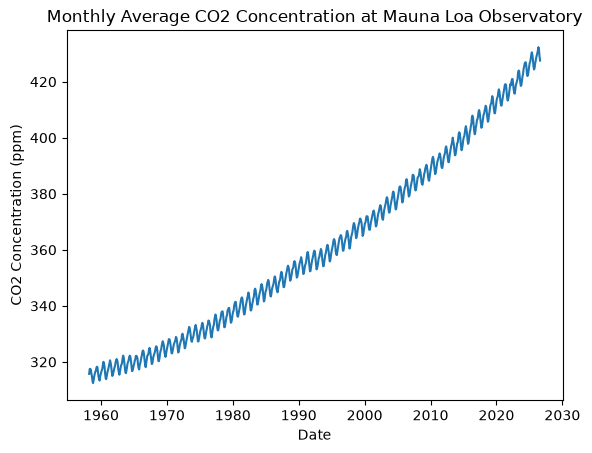

In [ ]:
fig, ax = plt.subplots()

ax.plot(co2_df.index, co2_df['average'])

ax.set_title('Monthly Average CO2 Concentration at Mauna Loa Observatory')
ax.set_xlabel('Date')
ax.set_ylabel('CO2 Concentration (ppm)')

plt.show()

However, for quick insights, you don't necessarily need to set up a full `matplotlib` setup. 

Below, we can quickly plot the `average` column by selecting it, and using the `plot` function.

<Axes: xlabel='datetime'>

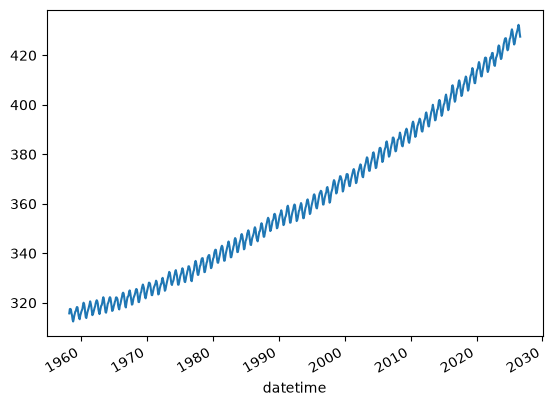

In [39]:
co2_df['average'].plot()

In fact, sd can recreate the first image exactly by providing the `title`, `xlabel`, and `ylabel` as arguments.

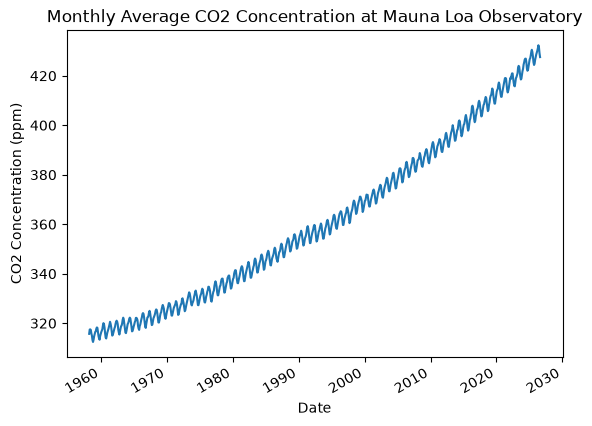

In [40]:
co2_df['average'].plot(
    title='Monthly Average CO2 Concentration at Mauna Loa Observatory',
    xlabel='Date',
    ylabel='CO2 Concentration (ppm)'
)

plt.show()

For more complex plots, I would recommend sticking to the `ax.plot()` format: it makes things clear and explicit. However, you can also mix and match these by setting the `ax` column within the `pandas` `plot` function. 

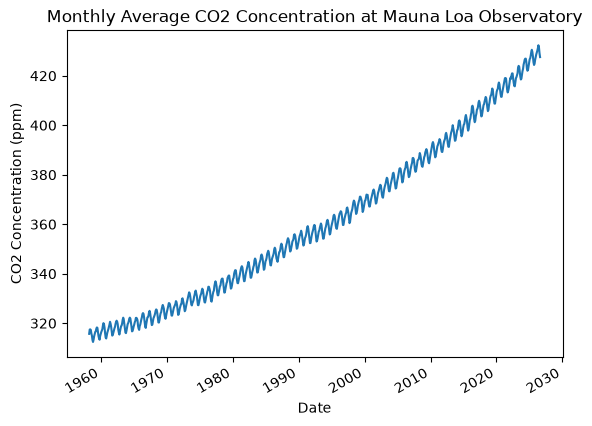

In [19]:
fig, ax = plt.subplots()

co2_df['average'].plot(ax=ax)

ax.set_title('Monthly Average CO2 Concentration at Mauna Loa Observatory')
ax.set_xlabel('Date')
ax.set_ylabel('CO2 Concentration (ppm)')

plt.show()

All of these methods ended up with the same output!

We can also have other quick exploratory plots - for instance, a histogram of total values.

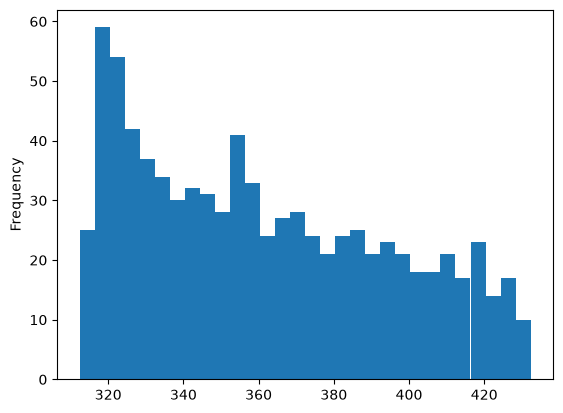

In [20]:
co2_df['average'].plot.hist(bins=30)

plt.show()

### Basic statistics

We can also gather exploratory statitics for our dataframe - at the highest level, from the `df.describe()` function:

In [21]:
co2_df.describe()

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
count,822.000000,822.000000,822.000000,822.000000,822.000000,627.000000,626.000000,628.000000
mean,1991.917275,6.492701,1992.416069,361.360474,361.349088,25.438596,0.508674,0.194586
std,19.788725,3.445673,19.787067,33.456190,33.387729,4.132082,0.201376,0.081352
min,1958.000000,1.000000,1958.202700,312.420000,314.440000,2.000000,0.150000,0.000000
25%,1975.000000,4.000000,1975.312525,331.282500,330.882500,24.000000,0.360000,0.140000
50%,1992.000000,6.000000,1992.416650,356.360000,356.490000,26.000000,0.480000,0.180000
75%,2009.000000,9.000000,2009.520850,387.682500,387.712500,28.000000,0.620000,0.230000
max,2026.000000,12.000000,2026.625000,432.340000,429.510000,31.000000,1.310000,0.580000


Note that not all of these are particularly useful for every dataset (it is perhaps unsurprising to find out that the average month is `6`), and as we know our dataset has a temporal trend it might not be very useful at all, but it can provide useful high-level descriptive overview for a lot of datasets.

We can view specific statistics by being more selective with our function, or even selecting specific columns:

In [22]:
co2_df.mean()

year              1991.917275
month                6.492701
decimal date      1992.416069
average            361.360474
deseasonalized     361.349088
ndays               25.438596
sdev                 0.508674
unc                  0.194586
dtype: float64

In [23]:
av_c02 = co2_df['average'].mean()

print(f"The average CO2 concentration at Mauna Loa Observatory since 1958 has been {av_c02:.2f} ppm.")

The average CO2 concentration at Mauna Loa Observatory since 1958 has been 361.36 ppm.


### Subsetting using `datetime`

This is great - but we know that CO<sub>2</sub> has been increasing over the years. Can we begin to use to temporal capability of `pandas` to plot things in a slightly more sensible way?

Using the `dt` functions, we can begin to subset the data. We know that 30 years is a useful time period over which to assess climate. Let's calculate means for 1960-1989 and 1990-2019:

In [24]:
# Get the average CO2 concentration for 1960-1990 
co2_df_period_1 = co2_df[
    (co2_df.index.year >= 1960) &  # Index slice for years greater than or equal to 1960, AND...
    (co2_df.index.year < 1990)     # where the year is less than 1990
]

co2_av_period_1 = co2_df_period_1['average'].mean()

print(f"The average CO2 concentration at Mauna Loa Observatory between 1960 and 1990 was {co2_av_period_1:.2f} ppm.")


# Now do the same for the period 1990-2020
co2_df_period_2 = co2_df[
    (co2_df.index.year >= 1990) &  # Index slice for years greater than or equal to 1990, AND...
    (co2_df.index.year < 2020)     # where the year is less than 2020
]

co2_av_period_2 = co2_df_period_2['average'].mean()

print(f"The average CO2 concentration at Mauna Loa Observatory between 1990 and 2020 was {co2_av_period_2:.2f} ppm.")


The average CO2 concentration at Mauna Loa Observatory between 1960 and 1990 was 332.27 ppm.
The average CO2 concentration at Mauna Loa Observatory between 1990 and 2020 was 379.92 ppm.


It might also be useful to group by different components. 

For instance, we can see that the trend has a seasonal signal - can we get the seasonal averages across all years? Yes - we can do this using the `groupby` method to get statistical measures across a given 'group' - here, the month, but this could just as easily be - e.g. - year, or a certain study site name (columns can be strings as well!)

In [25]:
# Group by month, select only the 'average' column, and then calculate the mean for each month
monthly_co2 = co2_df.groupby('month')['average'].mean()

monthly_co2

month
1     361.566324
2     362.350294
3     362.505797
4     363.800725
5     364.391449
6     363.829710
7     362.283333
8     360.265072
9     357.747206
10    357.811029
11    359.160294
12    360.483382
Name: average, dtype: float64

We can plot this:

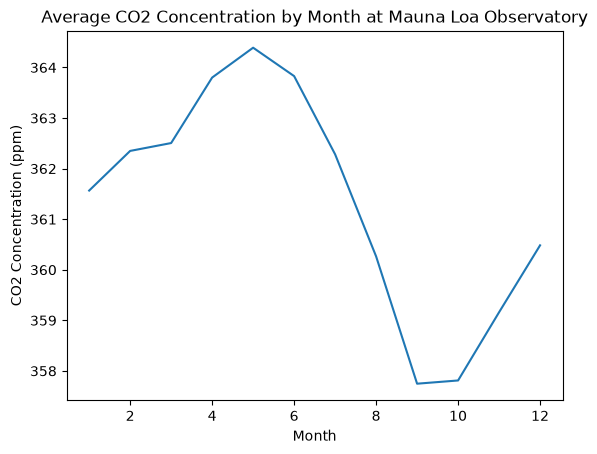

In [26]:
monthly_co2.plot(
    title='Average CO2 Concentration by Month at Mauna Loa Observatory',
    ylabel='CO2 Concentration (ppm)',
    xlabel='Month'
)

plt.show()

### Resampling

We could also use `groupby()` to get annual averages through time:

In [27]:
# Get annual average CO2 concentration for each year
annual_co2 = co2_df.groupby(co2_df.index.year)['average'].mean()

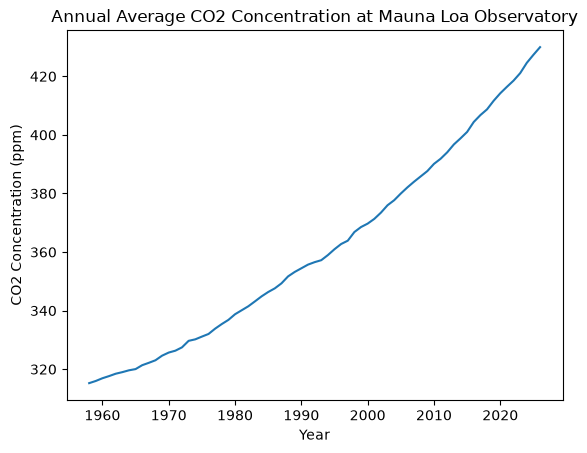

In [28]:
annual_co2.plot(
    title='Annual Average CO2 Concentration at Mauna Loa Observatory',
    ylabel='CO2 Concentration (ppm)',
    xlabel='Year'
)

plt.show()

However, pandas has a useful additional tool for time-series only: resampling.

This is useful if we wish to both _increase_ and _decrease_ the resolution of a dataset. You can provide a string to the `.resample()`. For instance, let's try and resample at 10-year intervals instead:

<Axes: xlabel='datetime'>

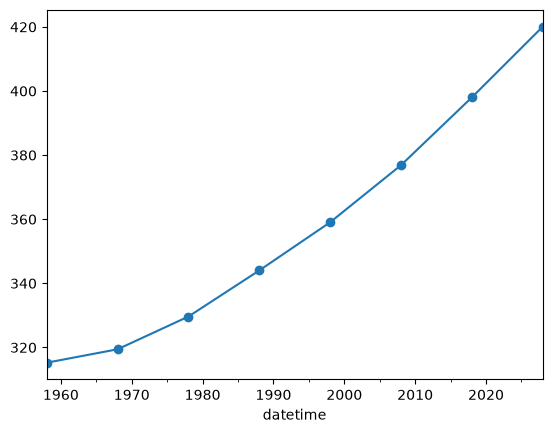

In [29]:
decadal_co2 = co2_df.resample('10YE')['average'].mean()

decadal_co2.plot(marker='o')

Your range of options for resampling is outlined below:

| Category | Alias String | Description | Example Usage |
| --- | --- | --- | --- |
| **Year** | `YE` | Year end (calendar) | `"1YE"`, `"5YE"` |
|  | `YS` | Year start (calendar) | `"1YS"` |
|  | `BQE` | Business quarter end | `"1BQE"` |
| **Quarter** | `QE` | Quarter end | `"1QE"` |
|  | `QS` | Quarter start | `"2QS"` |
| **Month** | `ME` | Month end | `"1ME"`, `"3ME"` |
|  | `MS` | Month start | `"1MS"` |
|  | `BME` | Business month end | `"1BME"` |
| **Week** | `W` | Weekly | `"1W"`, `"2W"` |
|  | `W-MON` | Weekly on Mondays (also `-TUE`, `-WED`, etc.) | `"1W-MON"` |
| **Day** | `D` | Calendar day | `"1D"`, `"7D"` |
|  | `B` | Business day | `"1B"`, `"5B"` |
| **Sub-Daily** | `h` / `h` | Hourly | `"1h"`, `"6h"` |
|  | `min` / `min` | Minute | `"1min"`, `"5min"` |
|  | `s` | Second | `"1s"`, `"30s"` |
|  | `ms` | Millisecond | `"100ms"` |
|  | `us` | Microsecond | `"500us"` |

Note that some of the options feel slightly business-related: this reflects the origin of `pandas` as an economics tool.

You can choose to _increase_ the resolution (upsampling) rather than reduce it (downsampling). When upsampling, rather than selecting a method such as `.mean()`, `.median()`, or `.sum()`, you will have to choose an interpolation method (e.g. `.interpolate(method='linear')`, or `'nearest'` - more information [here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.interpolate.html)).

Another option is not to _resample_ but to calculate a _rolling_ statistic - such as the `.rolling()` monthly average. This keeps the monthly resolution of the dataset, but allows you to find statistical averages over larger windows. This could be another valid way of presenting this dataset, due to the strong seasonality: in fact, it is what is presented on the [main Mauna Loa trend page](https://gml.noaa.gov/ccgg/trends/). Let's try and replicate this graph:

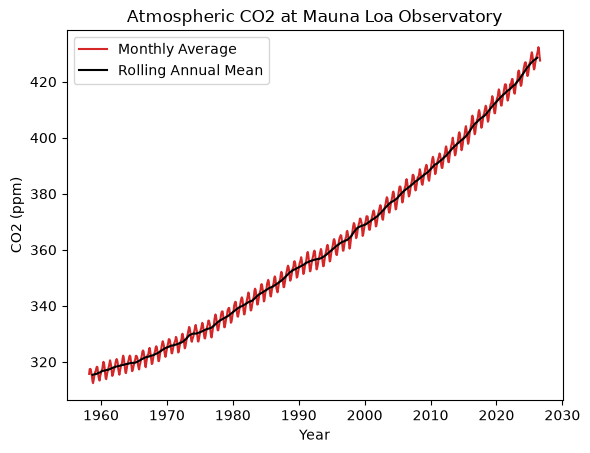

In [30]:
# Calculate a rolling 12-month mean, centred on the current month
co2_df['average_smoothed'] = co2_df['average'].rolling(window=12, center=True).mean()

# Replicate the Mauna Loa CO2 plot from the NOAA website, which shows both the monthly average and the rolling annual mean
fig, ax = plt.subplots()

ax.plot(co2_df.index, co2_df['average'], color='tab:red', label='Monthly Average')
ax.plot(co2_df.index, co2_df['average_smoothed'], color='k', label='Rolling Annual Mean')

ax.legend()

ax.set_xlabel('Year')
ax.set_ylabel('CO2 (ppm)')

ax.set_title('Atmospheric CO2 at Mauna Loa Observatory')

plt.show()

Compared to the webite figure, this looks pretty similar!

### Applying operations to a dataframe

These are all very handy functions to accelerate your analysis, but don't forget that you can manipulate `pandas` columns in the same way we can manipulate any other 1-D array in python - particularly analogous to `numpy` arrays.

For instance, the CO<sub>2</sub> data comes in units of ppm (parts per million) - we can create a new column with units in ppb (parts per billion) as follows:

In [31]:
co2_df['average_ppb'] = co2_df['average'] * 1000


# Select just two columns of the DataFrame to display by providing a list of column names to the DataFrame
co2_df[['average', 'average_ppb']]

,average,average_ppb
datetime,,
1958-03-15,315.71,315710.0
1958-04-15,317.45,317450.0
1958-05-15,317.51,317510.0
1958-06-15,317.27,317270.0
1958-07-15,315.87,315870.0
...,...,...
2026-04-15,431.12,431120.0
2026-05-15,432.34,432340.0
2026-06-15,431.43,431430.0


Importantly, any column can be treated as a 1-D array and plugged into a wide variety of other tools.

For instance, one capability we haven't addressed yet is the ability to perform more advanced statistical analysis. This functionality is provided by a range of Python packages, but one of the most common is `scipy`, via the `stats` module. See if you have already installed it as a dependency by trying to run the below:

In [32]:
from scipy import stats

If not, remember you can install the package into your environment using `conda install -c conda-forge scipy`.

Once it is installed, [`scipy.stats` has a `linregress` function](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.linregress.html) to perform linear regression. It will accept Pandas dataseries (generally converting to `numpy` arrays for the full operation), so we can regress the date of the observation against the CO<sub>2</sub> concentration as below:

In [33]:

results = stats.linregress(co2_df['decimal date'], co2_df["average"])

# The 'results' object returned by linregress contains several attributes, 
# including slope, intercept, rvalue, pvalue, and stderr. You can access 
# these attributes to get the results of the linear regression analysis.

print(f"Slope: {results.slope:.2f}")
print(f"R-squared: {results.rvalue**2:.2f}")
print(f"p-value: {results.pvalue:.4f}")

Slope: 1.67
R-squared: 0.98
p-value: 0.0000


There you have it: there is a staitically significant positive linear relationship between time and atmospheric CO<sub>2</sub> levels, rising at approximately 1.67 ppm/yr. I don't think this is a surprise to anyone!

It is worth highlighting are [numerous further statistical tests available to you](https://docs.scipy.org/doc/scipy/reference/stats.html) within `scipy`, as well as more advanced mathematical capability if you are interested (signal processing, linear algebra, integration and differentiation, discrete fourier transforms...), some capability of which is duplicated by `numpy`. Once again, this course has no chance of covering every capability of every package in detail: what is important is that you are aware this capability exists; you have the foundational knowledge to search for the answers you are looking for; and the ability to integrate this into your own work!

## Exporting data

If we have made modifications to our `DataFrame` (or created a new dataframe from scratch), it is probably of value to you to to want to save a copy to your own files. Much as we have a `read_csv()` function and similar, we also have a `to_csv()` function to write the data (see also: `to_excel()` and a variety of further more exotic options, such as `to_json()` and `to_parquet()`).

At its most basic, you can write as follows:

In [34]:
co2_df.to_csv('co2_mm_mlo_cleaned.csv')

You can provide a full path, such as `C:\path\to\your\directory\co2_mm_mlo_cleaned.csv` on Windows or `/path/to/your/directory/co2_mm_mlo_cleaned.csv` on MacOS to save the file in a specific location. Otherwise, it will save to the same location as your Jupyter Notebook.

### More advanced work with files

An advanced topic to consider in the future is how to process lots of files in sequence.

Nearly all the common (geospatial) data science packages we will be using have the ability to read and write files, but it’s worth highlighting two Standard Library tools that are valuable for interaction with your file system: `os` and `glob`.

`os` (standing for Operating System, of course), provides various miscellaneous functionality that approximate what you can do in the command line interface - for instance, `os.pwd()` to print your current directory, `os.path.exists('path/to/file.txt')` to check if a given filepath exists, or `os.path.basename('path/to/file.txt')` to strip the filepath of everything but the basename (i.e. returning `file.txt` in this example). We can also create new directories in the current directory:

In [35]:
import os

# Make a directory called sample_data, if it doesn't already exist
if not os.path.exists("sample_data"):
    os.mkdir("sample_data")

Now lets set up some more data to show how we can build on this to iterate through large amounts of files.

In the below cell, I do a few things using tools you have seen so far. I first check to see if a directory called `sample_input` exists in the directory `sample_data`. If it doesn’t exist (`if not os.path.exists(dir_path)`), I create it (`os.mkdir(dir_path)`). I then loop through a range of years 2020-2025, generating a pandas dataframe that contains two columns: the first all the dates in the year, and the second a series of random values (using `numpy`).

In [36]:
# Create a directory called sample_input inside sample_data, if it doesn't already exist.
# Note that here we use os.path.join to create the path, rather than writing it as a string.
# This will create the correct path regardless of the operating system (Windows, macOS, Linux).
dir_path = os.path.join("sample_data", "sample_input")

# Create directory if it doesn't exist
if not os.path.exists(dir_path):

    # Make directory
    os.mkdir(dir_path)

    # Generate random data for CSV files 2020-2025
    for year in range(2020, 2026):
        dates = pd.date_range(start=f"{year}-01-01", end=f"{year}-12-31", freq="D")[:365]
        values = np.random.rand(len(dates)) * 100  # random values
        df = pd.DataFrame({"date": dates, "values": values})
        file_path = os.path.join(dir_path, f"data_{year}.csv")
        df.to_csv(file_path, index=False)

Anyway, the important thing is to imagine not that we have just created this data, but that we have a directory full of tens or hundreds of iteratively named data files (kind of like what we have with our `data_2020.csv` through `data_2025.csv` files). How can we begin to interact with these programatically?

One key was is using the `glob` standard library. glob allows us to search our file system for standardise file names using pattern matching. Below, we construct a glob search for files in the format `"./sample_data/sample_input/data_*.csv"`, where `*` just means “fill in the blanks”. It returns a list of files that match, which we `print`. See that we get a list of all the matching files in the folder!

In [37]:
import glob

search_pattern = os.path.join(dir_path, "data_*.csv")

# Find all csv files
csv_files = glob.glob(search_pattern)

for f in csv_files:
    print(f)

sample_data/sample_input/data_2021.csv
sample_data/sample_input/data_2020.csv
sample_data/sample_input/data_2022.csv
sample_data/sample_input/data_2023.csv
sample_data/sample_input/data_2024.csv
sample_data/sample_input/data_2025.csv


Now, we have the ability to use our existing tools - such as looping and functions - to open these data sequentially and do interesting things with them. For now, we will just plot these on the same plot. However, imagine you had 1000 files that needed some slightly more complex processing applied. You could loop through all 1000 files, apply the processing to each one, and export them under new standard names to a new location. Hopefully this begins to show just how powerful programming can be…

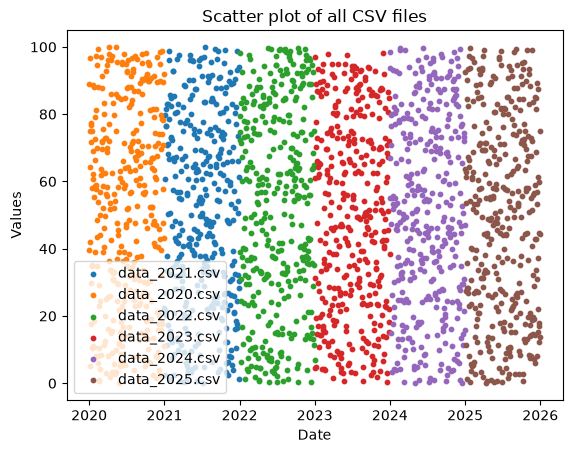

In [38]:
fig, ax = plt.subplots()

for file in csv_files:
    df = pd.read_csv(file, parse_dates=["date"])
    ax.scatter(df["date"], df["values"], s=10, label=os.path.basename(file))

ax.set_title("Scatter plot of all CSV files")
ax.set_xlabel("Date")
ax.set_ylabel("Values")
ax.legend()

plt.show()